In [1]:
import numpy as np
import r2l
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
np.random.seed(0)
ncol, nrow = 12, 4
env = r2l.CliffWalkingEnv_ch5(ncol, nrow)
epsilon = 0.1
alpha = 0.1
gamma = 0.9
agent = r2l.QLearning(ncol, nrow, epsilon, alpha, gamma)
num_episodes = 500 # 智能体在环境中运行的序列数量

return_list = [] # 记录每一条序列的回报

for i in range(10):
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episodes in range(int(num_episodes/10)): # 每个进度条的序列数
            episode_return = 0
            state = env.reset()
            done = False
            while not done:
                action = agent.take_action(state)
                next_state, r, done= env.step(action)
                episode_return += r
                agent.update(state, action, r, next_state)
                state = next_state

            return_list.append(episode_return)
            if (i_episodes + 1) % 10 ==0: # 每10条序列打印一下这10条序列的平均回报
                pbar.set_postfix({'episode' : '%d' % (num_episodes / 10 * i +
                    i_episodes), 'return' : '%.3f' % np.mean(return_list[-10:])})
            pbar.update(1)

Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 18514.63it/s, episode=499, return=-61.700]


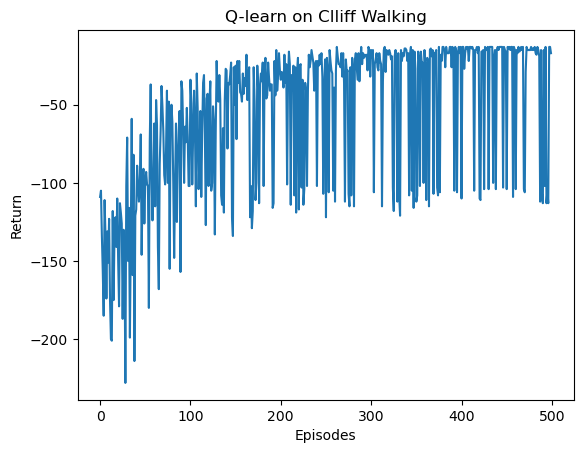

In [5]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Return')
plt.title('Q-learn on {}'.format('Clliff Walking'))
plt.show()

In [7]:
action_meaning = ['⬆️', '⬇️', '⬅️', '➡️', ] # gym 预先设定好的动作含义
print('Q-learning 算法最终收敛得到的策略：')
r2l.print_agent_ch4(agent, env, action_meaning, list(range(37, 47)), [47])


Q-learning 算法最终收敛得到的策略：
⬆️🅾️🅾️🅾️ 🅾️⬇️🅾️🅾️ 🅾️⬇️🅾️🅾️ ⬆️🅾️🅾️🅾️ ⬆️🅾️🅾️🅾️ 🅾️⬇️🅾️🅾️ 🅾️🅾️🅾️➡️ ⬆️🅾️🅾️🅾️ ⬆️🅾️🅾️🅾️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️⬇️🅾️🅾️ 
🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ ⬆️🅾️🅾️🅾️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️⬇️🅾️🅾️ 
🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️🅾️🅾️➡️ 🅾️⬇️🅾️🅾️ 
⬆️🅾️🅾️🅾️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ✅✅✅✅ 
